# Computing the probability distribution of ring parameters from observed stellar density
## By Jorge I. Zuluaga, Pablo Agudelo, David Kipping

## Formulation of the problem

Using transity photometry of an exoplanet we have obtained the posterior probability distribution function (pdf) of the observed stellar density ($\rho_\mathrm{obs}$) of the host star. We also have estimations of the stellar mass $M_\star$ and radius $R_\star$ (mean values and errors), and therefore of the stellar true density $\rho_\mathrm{true}$ (a pdf).

Our goal is to determine the probability distribution function (pdf) of the planet and ring properties (size and orientation) that better explain the observed stellar density, provided the true stellar density.

## Available information

Information we assume it is known without any uncertainty:

- Planetary orbit eccentricity, $e_\mathrm{orb}$
- Planetart orbit inclination, $i_\mathrm{orb}$ or impact parameter $b$.
- Transit depth, $p$.
- Planet mass, $M_p$.

Information that are part of the transit photometry fitting procedure

- Planet orbit semimajor axis, $a_\mathrm{orb}$, which is normally expressed as a ratio $a_\mathrm{orb}/R_\star$
- Planet orbital period, $P_\mathrm{orb} = P_\mathrm{orb}(a,M_\star)$
- Ringless planet radius, $R_p^0 = (pR_\star^2)^{1/2}$.

Information that we know with errors or pdf:

- Posterior distribution of the observed stellar density, $p(\rho_\mathrm{obs})$.

- Stellar mass $M_\star$ and radius $R_\star$ are assumed to follow a simple (truncated) multivariate normal distribution function, $g(M_\star,R_\star) = N_{T}(\{\bar M_\star,\bar R_\star\};\Sigma)$.

- We assume that we know the mean observed value $\bar M_\star$ and $\bar R_\star$ and have an estimation of the standard deviadtion $\sigma_M$ and $\sigma_R$.

- For more complicated cases, for instance, when we have the pdf of the true stellar density $f(\rho_\star)$, we may play with the (unknown) correlation factor $\rho_{MR}$ to reconstruct $f(\rho_\star)$ from $g(M_\star,R_\star)$.

Information we want to determine:

- Planetary radius for a ringed planet, $R_p$. Units: meters. Potential range: [$R_p^\mathrm{min} = R_\oplus (M_p/M_\oplus)^{1/3}$, $R_p^\mathrm{max} = R_p^0$].
- Radius of the external ring, $f_e$ in units of $R_p$. $f_e=1$ means there are not rings. Units: adimensional. Potential range: [1,5].
- Inclination of the ring with respect to the orbit plane, $i_\mathrm{r}$. $i_\mathrm{r}=0$ means the rings are in the plane of the orbit. Units: degrees. Potential range: [0,90].
- Roll rotation of the ring, $\phi_\mathrm{r}$. $\phi_\mathrm{r}=0$ means that the node line of the ring are over the plane of the sky. Units: degrees. Potential range: [0,90].
- Normal optical depth of the ring, $\tau$. $\tau=0$ means the rings are transparent. Units: adimensional. Potential range: [0,5].

## Probability assumptions

Given a set of ringed-planet properties we can estimate the observed density:

$$
\rho_\mathrm{obs}(R_p,f_e,i_r,\phi_r;R_\star,M_\star)
$$

For simplicity we will assume that the probability of the planet parameters $q(R_p,f_e,i_r,\phi_r;R_\star,M_\star)$ is proportional to the observed stellar density, namely:

$$
q(R_p,f_e,i_r,\phi_r;R_\star,M_\star) \propto p(\rho_{obs}(R_p,f_e,i_r,\phi_r;R_\star,M_\star))
$$

**NOTE**: This is not strictly true. In fact, according to the coarea formula ([Wikipedia](https://en.wikipedia.org/wiki/Coarea_formula); [Negro, 2021](https://arxiv.org/pdf/2110.01441)) the relationship between both probability distributions will be:
$$
q(\mathbf{x})=\frac{p(\rho_\mathrm{obs}(\mathbf{x}))}{I(\rho_\mathrm{obs}(\mathbf{x}))}
$$
where he coarea factor is:
$$
I(\rho_\mathrm{obs}(\mathbf{x})) = \int_{L_{\rho_\mathrm{obs}(\mathbf{x})}} \frac{d S_{\mathbf{z}}}{\|\nabla \rho_\mathrm{obs}(\mathbf{z})\|}
$$
and $L_{\rho} = \{\mathbf{x} \in D \mid \rho_\mathrm{obs}(\mathbf{x})=\rho\}$ is a level set.

Estimating the coarea factor $I(\rho_\mathrm{obs}(\mathbf{x}))$ is not trivial due to the high dimensionality of the problem, we should remain that $\mathbf{x}:R_p,f_e,i_r,\phi_r,R_\star,M_\star$, and due to the fact that $\rho_\mathrm{obs}(\mathbf{x})$ is a numerical function that cannot be expressed in terms of elemental functions.  Although numerical procedures can be devised to estimate these factor, we have verified that it does not impact significantly generation of a random sample using the MCMC procedure. This is because in the Metropolis-Hasting algorithm, acceptance probability of a new sample $\mathbf{x}'$ will depend on the ratio:

$$
A\left(\mathbf{x} \rightarrow \mathbf{x}^{\prime}\right) = \frac{q(\mathbf{x'})}{q(\mathbf{x})} = \frac{p(\rho_\mathrm{obs}(\mathbf{x}'))}{p(\rho_\mathrm{obs}(\mathbf{x}))}
\frac{I(\rho_\mathrm{obs}(\mathbf{x}))}{I(\rho_\mathrm{obs}(\mathbf{x}'))}
$$

If we guarantee that the new sample $\mathbf{x}'$ is close to $\mathbf{x}$, and that the function $\rho_\mathrm{obs}(\mathbf{x})$ does not change significantly from one point to the other, then the ratio $I(\rho_\mathrm{obs}(\mathbf{x}))/I(\rho_\mathrm{obs}(\mathbf{x}'))$ is close to unit. We have performed numerical experiments to verify this.

## Implementation

In [1]:
import os
# Check if running in Google Colab
if 'COLAB_GPU' in os.environ:
    # Clone the repository
    !git clone -b refactor https://github.com/seap-udea/GeoTrans

    # Install gdown if not already installed
    !pip install -Uq gdown

    # Download the file using gdown
    # https://drive.google.com/file/d/1ZWFfb7vBHe4RMdCO71z7XDg41fSo-dB9/view?usp=drive_link
    !gdown 1ZWFfb7vBHe4RMdCO71z7XDg41fSo-dB9

    # Unzip the downloaded file
    !unzip -oq Kepler-51-data.zip

In [2]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('GeoTrans')
from geotrans2 import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
import pickle
from scipy.stats import norm
from tqdm import tqdm
import warnings
import multiprocess as mp
from scipy.stats import multivariate_normal
from ipywidgets import interact, FloatSlider
import time
from copy import deepcopy
import os
warnings.filterwarnings("ignore")

## Routines

In [3]:
def mcra_grid_general(S,props,store,adjust,Np,seed=None,verbose=False,default=False):
    
    # Noauto 
    noauto = S.noauto
    S.noauto = True

    # Seed 
    if seed is not None:
        np.random.seed(seed)

    # Arrays to store the values:
    Xs = []

    # Initialize spar
    # Store complimentary information
    spars = dict()
    for sprop,vals in store.items():
        spars[sprop] = getattr(S,vals['prop'])*vals['scale']

    # Maximum value of probabilities
    p_delta_max = 1/((2*np.pi)**0.5*S.delta_std)
    p_rho_obs_max = S.rho_obs_fun.y.max()
    if verbose:print(f"Maximum probabilities: p_delta_max: {p_delta_max}, p_rho_obs_max: {p_rho_obs_max}")

    i=0 # Main counter 
    n=0 # Counter of failed tests
    n_acceptances = [] # Number of tests before acceptance
    while i<Np:

        if verbose:print(f"Testing point: {n}")
        n+=1

        # Get a random point
        pars = dict()
        for prop,vals in props.items():
            if default:
                pars[prop] = vals['default']*vals['scale']
            else:
                pars[prop] = np.random.uniform(vals['range'][0], vals['range'][1]) * vals['scale']
        S.__dict__.update(pars)

        # Adjust parameters
        adjust(S)

        msg = ""
        for prop,vals in props.items():
            msg += f"{prop}: {getattr(S,prop)/vals['scale']}, "
        if verbose:print(f"Guess parameters: {msg.strip(', ')}")

        # Update system
        S.updateSystem()
        S.calculate_PR()

        # Store complimentary information
        spars = dict()
        for sprop,vals in store.items():
            spars[sprop] = getattr(S,vals['prop'])*vals['scale']

        # Compute probabilities
        p_rho_obs = float(S.rho_obs_fun(spars['rho_obs']))
        p_delta = float(S.delta_fun(spars['delta']))

        if verbose:print(f"\trho_obs: {spars['rho_obs']}, rho_true: {spars['rho_true']}, PR: {spars['PR']}, delta: {spars['delta']} (target {S.delta_mean})")
        if verbose:print(f"\tProbabilities: p_rho_obs: {p_rho_obs}, p_delta: {p_delta}")

        # Acceptance ratio
        alpha = p_rho_obs*p_delta / (p_rho_obs_max*p_delta_max)
        if verbose:print(f"\tAcceptance ratio: {alpha}")

        # Accept or reject
        u = np.random.rand()
        if verbose:print(f"\tRandom number: {u}")
        if u < alpha:
            # Sample parameters
            values = [pars[prop]/vals['scale'] for prop,vals in props.items()]
            svalues = [spars[prop] for prop in store.keys()]
            Xs.append(values + svalues)
            if verbose:print("\tAccepted")
            i += 1
            n_acceptances += [n]
            n = 0
        else:
            if verbose:print("\t\tRejected")

    if verbose:print(f"Acceptance rate: {np.mean(n_acceptances)} test per accepted sample")
    columns = [prop for prop,vals in props.items()]
    scolumns = [prop for prop,vals in spars.items()]
    Xs = pd.DataFrame(Xs,columns=columns + scolumns)

    S.noauto = noauto

    return Xs

def parallel_mcra_grid(S, props, store, adjust, num_processes=1, Ns=100):
    
    # Define the number of iterations for each process
    num_iterations = Ns // num_processes

    # Function to run the grid
    def run_grid(seed):
        return mcra_grid_general(S, props, store, adjust, num_iterations, seed=seed)

    # Launch the grids in parallel
    with mp.Pool(processes=num_processes) as pool:
        results = pool.map(run_grid, range(num_processes))

    # Combine the results
    Xs = pd.concat(results, ignore_index=True)

    return Xs

def plotSample(Xs,S,props,rho_range=(500,4000),chargs=dict(),csargs=dict(),prefix="noprefix"):
    # ################################################
    # TARGET DISTRIBUTIONS
    # ################################################
    fig, axs = plt.subplots(1, 3, figsize=(12, 6))

    # First subplot
    axs[0].hist(Xs['rho_obs'], bins=30, density=True, alpha=0.5, label='MCMC Samples')
    x = np.linspace(500,4000,400)
    y = S.rho_obs_fun(x)
    axs[0].plot(x, y, 'r--', label='Interpolated Observed Density')
    y_true = S.rho_true_fun(x)
    axs[0].plot(x, y_true, 'b--', label='Interpolated True Density')
    axs[0].set_xlim(*rho_range)
    axs[0].set_xlabel(r'Observed Density [kg/m$^3$]')
    axs[0].set_ylabel('Frequency')
    axs[0].legend()

    # Second subplot
    axs[1].hist(Xs['delta'], bins=30, density=True, alpha=0.5, label='MCMC Samples')
    delta_values = np.linspace(Xs['delta'].min(), Xs['delta'].max(), 400)
    gaussian = S.delta_fun(delta_values)
    axs[1].plot(delta_values, gaussian, 'r--', label='Gaussian Distribution')
    axs[1].set_xlabel('Delta')
    axs[1].set_ylabel('Frequency')
    axs[1].legend()

    # Third subplot
    axs[2].hist(Xs['rho_true'], bins=4, density=True, alpha=0.5, label='MCMC Samples')
    x = np.linspace(500,4000,400)
    y = S.rho_true_fun(x)
    axs[2].plot(x, y, 'r--', label='Interpolated True Density')
    axs[2].set_xlim(*rho_range)
    axs[2].set_xlabel(r'True Density [kg/m$^3$]')
    axs[2].set_ylabel('Frequency')
    axs[2].legend()

    plt.tight_layout()
    plt.savefig(f"figures/target_distributions-{prefix}.png")
    plt.show()

    # ################################################
    # PARAMETER'S CONTOURS
    # ################################################
    columns = [prop for prop,vals in props.items()]
    data = np.array(Xs[columns])

    G=PlotGrid(props,figsize=3)

    hargs=dict(alpha=1,bins=10,density=False,colorbar=1,cmap="rainbow")
    hargs.update(chargs)
    G.plotHist(data,**hargs)

    sargs=dict(c='r',marker='.',s=2,edgecolors='none',alpha=0.3)
    sargs.update(csargs)
    G.scatterPlot(data,**sargs)
    G.fig.savefig(f"figures/corner_posteriors-{prefix}.png")

    # ################################################
    # PARAMETER'S POSTERIORS
    # ################################################
    fig, axs = plt.subplots(1, len(props), figsize=(18, 6))

    for i, (prop, vals) in enumerate(props.items()):
        axs[i].hist(Xs[prop], bins=30, density=True, alpha=0.5, label=prop)
        axs[i].set_xlabel(prop)
        axs[i].set_ylabel('Frequency')
        axs[i].set_title(f'Histogram of {prop}')
        axs[i].legend()

    plt.tight_layout()
    plt.savefig(f"figures/parameters_posteriors-{prefix}.png")
    plt.show()

### Extract system properties

Name of the file: Kepler-51/Kepler-51b_45d/TTVplan3-post_equal_weights.dat
Orbital period: 45.15535633000001
Impact parameter: 0.12771068765405527


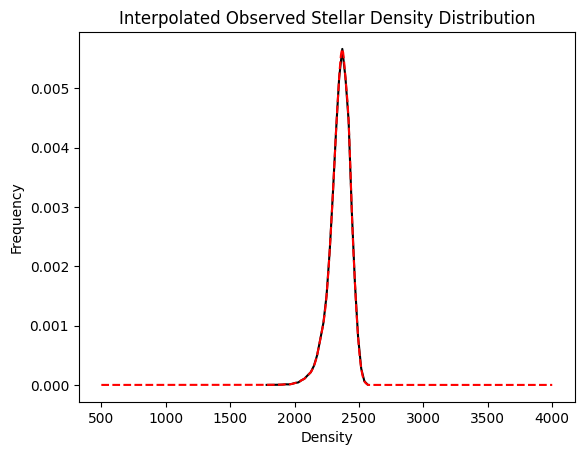

In [4]:
filename = 'Kepler-51/Kepler-51b_45d/TTVplan3-post_equal_weights.dat'
data = np.loadtxt(filename)

print(f"Name of the file: {filename}")
orbital_period = data[:, 3].mean()
print(f"Orbital period: {orbital_period}")
print(f"Impact parameter: {data[:,2].mean()}")

filename = 'Kepler-51/Kepler-51b_45d/rhob_samples.dat'
rho_obs_b = np.loadtxt(filename)

# Histogram
bins = int(len(rho_obs_b)/3000)
hs,rhos = np.histogram(rho_obs_b, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])

# Interpolated function
rho_obs_b_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)
with open('rho_obs_b_fun.pkl', 'wb') as f:
    pickle.dump(rho_obs_b_fun, f)

# Plot
plt.plot(rhos, hs, 'k-')

# Interpolated/Extrapolated values
x = np.linspace(500, 4000, 400)
y = rho_obs_b_fun(x)
plt.plot(x, y, 'r--')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('Interpolated Observed Stellar Density Distribution')
plt.show()

Planet d is instead Planet b:

Name of the file: Kepler-51/Kepler-51d_85d/TTVplan-post_equal_weights.dat
Orbital period: 85.3162
Impact parameter: 1.4189797969499185


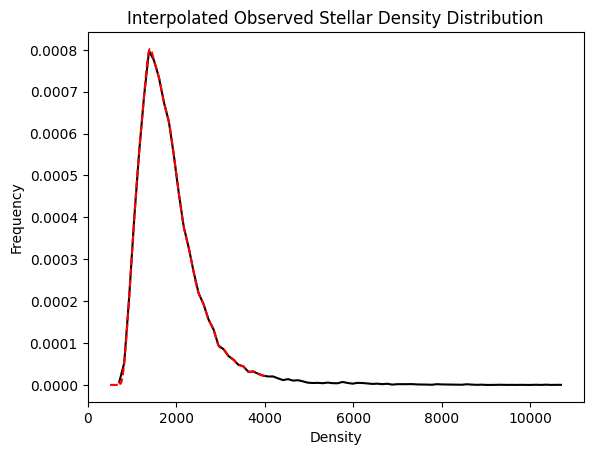

In [5]:
filename = 'Kepler-51/Kepler-51d_85d/TTVplan-post_equal_weights.dat'
data = np.loadtxt(filename)
rho_obs_c = data[:,1]

print(f"Name of the file: {filename}")
orbital_period = data[:, 3].mean()
print(f"Orbital period: {orbital_period}")
print(f"Impact parameter: {data[:,2].mean()}")

# Histogram
bins = int(len(rho_obs_c)/500)
hs,rhos = np.histogram(rho_obs_c, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])

# Interpolated function
rho_obs_c_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)
with open('rho_obs_c_fun.pkl', 'wb') as f:
    pickle.dump(rho_obs_c_fun, f)

# Plot
plt.plot(rhos, hs, 'k-')

# Interpolated/Extrapolated values
x = np.linspace(500, 4000, 400)
y = rho_obs_c_fun(x)
plt.plot(x, y, 'r--')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('Interpolated Observed Stellar Density Distribution')
plt.show()

Planet c is instead planet d

Name of the file: Kepler-51/Kepler-51c_130d/TTVplan-post_equal_weights.dat
Orbital period: 130.17802962
Impact parameter: 0.2531098694701528


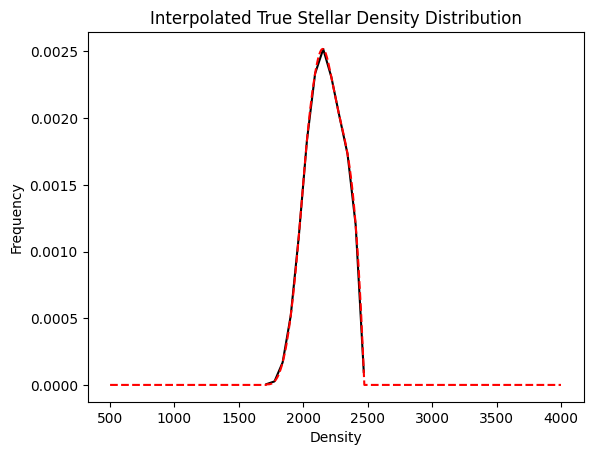

In [6]:
filename = 'Kepler-51/Kepler-51c_130d/TTVplan-post_equal_weights.dat'
data = np.loadtxt(filename)
rho_obs_d = data[:,1]

print(f"Name of the file: {filename}")
orbital_period = data[:, 3].mean()
print(f"Orbital period: {orbital_period}")
print(f"Impact parameter: {data[:,2].mean()}")

# Histogram
bins = int(len(rho_obs_d)/3000)
hs,rhos = np.histogram(rho_obs_d, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])

# Interpolated function
rho_obs_d_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)
with open('rho_obs_d_fun.pkl', 'wb') as f:
    pickle.dump(rho_obs_d_fun, f)

# Plot
plt.plot(rhos, hs, 'k-')

# Interpolated/Extrapolated values
x = np.linspace(500, 4000, 400)
y = rho_obs_d_fun(x)
plt.plot(x, y, 'r--')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('Interpolated True Stellar Density Distribution')
plt.show()

### Load all densities

In [7]:
# Unpickle the functions
with open('rho_true_fun.pkl', 'rb') as f:
    rho_true_fun = pickle.load(f)

with open('rho_obs_b_fun.pkl', 'rb') as f:
    rho_obs_b_fun = pickle.load(f)

with open('rho_obs_c_fun.pkl', 'rb') as f:
    rho_obs_c_fun = pickle.load(f)

with open('rho_obs_d_fun.pkl', 'rb') as f:
    rho_obs_d_fun = pickle.load(f)

All densities

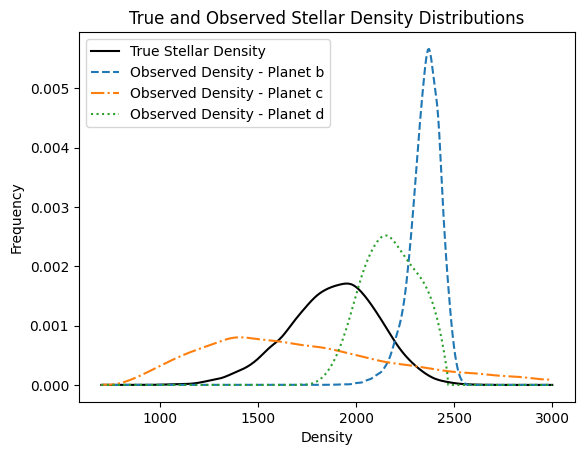

In [8]:
# Define the range for x-axis
x_range = np.linspace(700, 3000, 400)

# Plot rho_true_fun
plt.plot(x_range, rho_true_fun(x_range), label='True Stellar Density', color='black')

# Plot rho_obs_*_fun for each planet
plt.plot(x_range, rho_obs_b_fun(x_range), label='Observed Density - Planet b', linestyle='--')
plt.plot(x_range, rho_obs_c_fun(x_range), label='Observed Density - Planet c', linestyle='-.')
plt.plot(x_range, rho_obs_d_fun(x_range), label='Observed Density - Planet d', linestyle=':')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('True and Observed Stellar Density Distributions')
plt.legend()
plt.show()

### Stellar grid

In [9]:
df = pd.read_csv('Kepler-51/GKTHCatalog_Table4.csv')
k51 = df[df['id_starname'] == 'kic11773022']

rho_true_sun = MSUN/(4/3 * np.pi * RSUN**3)

M_mean = k51.iso_mass.values[0]
R_mean = k51.iso_rad.values[0]
M_std = (k51.iso_mass_err1.values[0] + abs(k51.iso_mass_err2.values[0]))/2
R_std = (k51.iso_rad_err1.values[0] + abs(k51.iso_rad_err2.values[0]))/2

print(f"Mass: {M_mean} +/- {M_std}")
print(f"Radius: {R_mean} +/- {R_std}")

Mass: 0.9146640833784588 +/- 0.04980093747925855
Radius: 0.8688315952605846 +/- 0.02891379267492005


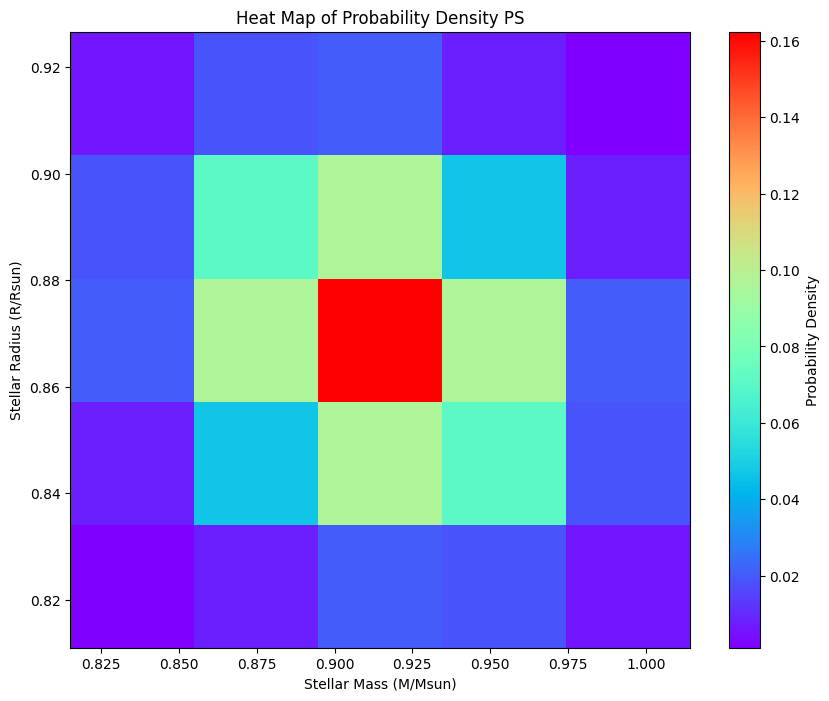

Minimum: 0.0010944907754310371, Maximum: 0.16243683359034986


In [10]:
Ms_mean = M_mean*MSUN
Ms_std = M_std*MSUN
Rs_mean = R_mean*RSUN
Rs_std = R_std*RSUN

Ng = 5
ts = 2
MS, RS = np.meshgrid(
    np.linspace(Ms_mean - ts*Ms_std, Ms_mean + ts*Ms_std, Ng)/MSUN,
    np.linspace(Rs_mean - ts*Rs_std, Rs_mean + ts*Rs_std, Ng)/RSUN
)
delta_Ms = MS[0,1] - MS[0,0]
delta_Rs = RS[1,0] - RS[0,0]

mean = [M_mean, R_mean]
rho_MR = -0.2
cov = [
    [M_std**2, rho_MR * M_std * R_std], 
    [rho_MR * M_std * R_std, R_std**2]
]
PS = np.zeros(MS.shape)
for i in range(MS.shape[0]):
    for j in range(RS.shape[1]):
        PS[i, j] = multivariate_normal.pdf([MS[i, j], RS[i, j]], mean=mean, cov=cov)
PS = PS*delta_Ms*delta_Rs

plt.figure(figsize=(10, 8))
plt.imshow(PS, extent=[MS.min(), MS.max(), RS.min(), RS.max()], 
           origin='lower', aspect='auto', cmap='rainbow')
plt.colorbar(label='Probability Density')
plt.xlabel('Stellar Mass (M/Msun)')
plt.ylabel('Stellar Radius (R/Rsun)')
plt.title('Heat Map of Probability Density PS')
plt.show()

print(f"Minimum: {PS.min()}, Maximum: {PS.max()}")

Density:

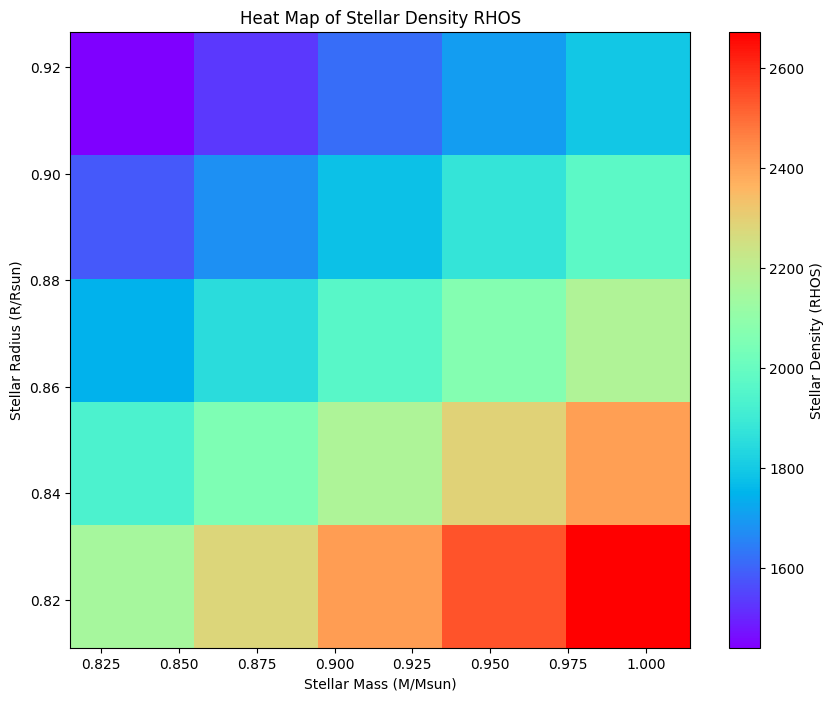

Minimum: 1440.1601617311885, Maximum: 2673.3940642107623


In [11]:
RHOS = MS/(RS**3)*rho_true_sun
plt.figure(figsize=(10, 8))
plt.imshow(RHOS, extent=[MS.min(), MS.max(), RS.min(), RS.max()], 
           origin='lower', aspect='auto', cmap='rainbow')
plt.colorbar(label='Stellar Density (RHOS)')
plt.xlabel('Stellar Mass (M/Msun)')
plt.ylabel('Stellar Radius (R/Rsun)')
plt.title('Heat Map of Stellar Density RHOS')
plt.show()

print(f"Minimum: {RHOS.min()}, Maximum: {RHOS.max()}")

### Planet information

In [148]:
def adjust_params(S,verbose=False):
    # Given Porb and Mstar calculate ap
    S.ap = ((GCONST * S.Mstar * S.Porb_mean**2) / (4 * pi**2))**(1/3)
    if verbose:print(f"Semimajor axis: {S.ap/AU:.4f} au = {S.ap/S.Rstar:.2f} Rs")

    # Given Borb and ap calculate iorb
    S.iorb = np.arccos(S.borb_mean*S.Rstar/S.ap)
    if verbose:print(f"Orbital inclination: {S.iorb*RAD:.2f} degrees")

    S.updateSystem()

Propeties of the system are available at: https://exoplanetarchive.ipac.caltech.edu/overview/Kepler-51

In [149]:
# https://exoplanetarchive.ipac.caltech.edu/overview/Kepler-51
# Planet b: Masuda et al. 2024

# Columns are: Rp/R*, rho* (km/m^3), b, P (ignore), tmid,0 (ignore), q1, q2
data = np.loadtxt('Kepler-51/Kepler-51b_45d/TTVplan3-post_equal_weights.dat')

# ########################################################
# Observables level 1: theoretically independent
# ########################################################
# These are the observables that depends on few astrophysical parameters
# For instance: detemining the transit depth depends on few parameters

# ============================
# TRANSIT DEPTH
# ============================
# delta_mean = None; delta_std = None
qdelta = 0 # Make 1 if you have delta values

# If Rp and Rstar is known:
Rp_mean = 0.609*RJUP # Masuda et al. 2024
Rp_std = 0.012*RJUP # Masuda et al. 2024

delta_mean = (Rp_mean/Rs_mean)**2
delta_std = 2*delta_mean*(Rp_std/Rp_mean + Rs_std/Rs_mean)
print(f"Transit depth: {delta_mean*100:.2f} +/- {delta_std*100:.2f} %")

# ============================
# TRANSIT PERIOD
# ============================
# Orbital period
Porb_mean = 45.15405*DAY # Masuda et al. 2024
Porb_std = 0.00039*DAY # Masuda et al. 2024

# ########################################################
# Observables level 2: model dependent parameters
# ########################################################
# ============================
# IMPACT PARAMETER
# ============================
borb_mean = data[:,2].mean()
borb_sdt = data[:,2].std()
print(f"Impact parameter fitting: {borb_mean} +/- {borb_sdt}")

borb_mean = 0.0740 # Masuda et al. 2024
borb_std = 0.0720 # Masuda et al. 2024
print(f"Impact parameter literature: {borb_mean} +/- {borb_sdt}")

# ########################################################
# Observables level 2: dependent parameters
# ########################################################
# These are observables that can be calculated from previous parameters
# ============================
# PLANETARY RADIUS
# ============================
# These are the observables that depends on previous parameters
if qdelta:
    Rp_mean = delta_mean**0.5*Rs_mean
    Rp_std = 0.5*Rp_mean*(delta_std/delta_mean + 2*Rs_std/Rs_mean)

print(f"Planet radius: {Rp_mean/RJUP:.4f} +/- {Rp_std/RJUP:.4f} RJup")

# ============================
# SEMIMAJOR AXIS
# ============================
# Semimajor axis
ap_mean = ((GCONST * Ms_mean * Porb_mean**2) / (4 * pi**2))**(1/3)
ap_std = 1/3*ap_mean*(Ms_std/Ms_mean + 2*Porb_std/Porb_mean)
print(f"Semimajor axis: {ap_mean/AU:.4f} +/- {ap_std/AU:.4f} au = {ap_mean/Rs_mean:.2f} Rs")

# ============================
# ORBITAL INCLINATION
# ============================
iorb_mean = np.arccos(borb_mean*Rs_mean/ap_mean)*RAD
iorb_std = np.sqrt((borb_sdt * Rs_mean / ap_mean)**2 + \
                   (borb_mean * Rs_std / ap_mean)**2 + \
                   (borb_mean * Rs_mean * ap_std / ap_mean**2)**2) * RAD
print(f"Orbital inclination: {iorb_mean:.2f} +/- {iorb_std:.2f} degrees")

# ########################################################
# Observavles level 3: other parameters
# ########################################################
# Planetary mass
Mp_mean = 0.011*MJUP
Mp_std = 0.007*MJUP

# ============================
# MINIMUM PLANET RADIUS
# ============================
Rp_min = REARTH*(Mp_mean/MEARTH)**(1/3)
fRp_min = Rp_min/Rp_mean
print(f"Minimum planet radius: {Rp_min/RJUP:.4f} RJup")
print(f"Minimum planet radius in terms of the ringless planet radius: {fRp_min:.4f} Rp")

System_b = RingedSystem(
    system = dict(
        Mstar=Ms_mean,
        Rstar=Rs_mean,
        Rplanet=Rp_mean, # Libby-Roberts et al. 2020
        Mplanet=Mp_mean, # Libby-Roberts et al. 2020
        ap=ap_mean, #Semi-major axis # Libby-Roberts et al. 2020
        iorb=iorb_mean*DEG, #Orbital inclination
        fe=1, #Exterior ring (Rp)
        fi=1, #Interior ring (Rp)
        ir=0.0*DEG, #Ring inclination
        phir=0.0*DEG, #Ring roll angle
        tau=1.0, #Opacity
    )
)

System_b.noauto = True

# Useful functions
System_b.Porb_mean = Porb_mean
System_b.borb_mean = borb_mean
System_b.delta_mean = delta_mean
System_b.delta_std = delta_std
System_b.delta_fun = lambda x:norm.pdf(x, delta_mean, delta_std)
System_b.rho_obs_fun = rho_obs_b_fun
System_b.rho_true_fun = rho_true_fun

# Adjust
print()
print("After adjustment:")
adjust_params(System_b,True)

System_b.calculate_PR()
print(f"rho_obs: {System_b.rho_obs}, rho_true: {System_b.rho_true}, PR: {System_b.PR}")

Transit depth: 0.50 +/- 0.05 %
Impact parameter fitting: 0.12771068765405527 +/- 0.09194155048630412
Impact parameter literature: 0.074 +/- 0.09194155048630412
Planet radius: 0.6090 +/- 0.0120 RJup
Semimajor axis: 0.2409 +/- 0.0044 au = 59.57 Rs
Orbital inclination: 89.93 +/- 0.09 degrees
Minimum planet radius: 0.1383 RJup
Minimum planet radius in terms of the ringless planet radius: 0.2271 Rp

After adjustment:
Semimajor axis: 0.2409 au = 59.57 Rs
Orbital inclination: 89.93 degrees
rho_obs: 1960.2730428867958, rho_true: 1960.8074257658545, PR: -0.0001183752993038757


Done.

In [151]:
# https://exoplanetarchive.ipac.caltech.edu/overview/Kepler-51
# Planet c: Masuda et al. 2024

# Columns are: Rp/R*, rho* (km/m^3), b, P (ignore), tmid,0 (ignore), q1, q2
data = np.loadtxt('Kepler-51/Kepler-51d_85d/TTVplan-post_equal_weights.dat')

# ########################################################
# Observables level 1: theoretically independent
# ########################################################
# These are the observables that depends on few astrophysical parameters
# For instance: detemining the transit depth depends on few parameters

# ============================
# TRANSIT DEPTH
# ============================
# delta_mean = None; delta_std = None
qdelta = 0 # Make 1 if you have delta values

# If Rp and Rstar is known:
Rp_mean = 0.57*RJUP # Masuda et al. 2024
Rp_std = 0.12*RJUP # Masuda et al. 2024

delta_mean = (Rp_mean/Rs_mean)**2
delta_std = 2*delta_mean*(Rp_std/Rp_mean + Rs_std/Rs_mean)
print(f"Transit depth: {delta_mean*100:.2f} +/- {delta_std*100:.2f} %")

# ============================
# TRANSIT PERIOD
# ============================
# Orbital period
Porb_mean = 85.3139*DAY # Masuda et al. 2024
Porb_std = 0.0020*DAY # Masuda et al. 2024

# ########################################################
# Observables level 2: model dependent parameters
# ########################################################
# ============================
# IMPACT PARAMETER
# ============================
borb_mean = data[:,2].mean()
borb_sdt = data[:,2].std()
print(f"Impact parameter fitting: {borb_mean} +/- {borb_sdt}")

borb_mean = 0.72 # 0.9880 # Masuda et al. 2024
borb_std = 0.0200 # Masuda et al. 2024
print(f"Impact parameter literature: {borb_mean} +/- {borb_sdt}")

# ########################################################
# Observables level 2: dependent parameters
# ########################################################
# These are observables that can be calculated from previous parameters
# ============================
# PLANETARY RADIUS
# ============================
# These are the observables that depends on previous parameters
if qdelta:
    Rp_mean = delta_mean**0.5*Rs_mean
    Rp_std = 0.5*Rp_mean*(delta_std/delta_mean + 2*Rs_std/Rs_mean)

print(f"Planet radius: {Rp_mean/RJUP:.4f} +/- {Rp_std/RJUP:.4f} RJup")

# ============================
# SEMIMAJOR AXIS
# ============================
# Semimajor axis
ap_mean = ((GCONST * Ms_mean * Porb_mean**2) / (4 * pi**2))**(1/3)
ap_std = 1/3*ap_mean*(Ms_std/Ms_mean + 2*Porb_std/Porb_mean)
print(f"Semimajor axis: {ap_mean/AU:.4f} +/- {ap_std/AU:.4f} au = {ap_mean/Rs_mean:.2f} Rs")

# ============================
# ORBITAL INCLINATION
# ============================
iorb_mean = np.arccos(borb_mean*Rs_mean/ap_mean)*RAD
iorb_std = np.sqrt((borb_sdt * Rs_mean / ap_mean)**2 + \
                   (borb_mean * Rs_std / ap_mean)**2 + \
                   (borb_mean * Rs_mean * ap_std / ap_mean**2)**2) * RAD
print(f"Orbital inclination: {iorb_mean:.2f} +/- {iorb_std:.2f} degrees")

# ########################################################
# Observavles level 3: other parameters
# ########################################################
# Planetary mass
Mp_mean = 0.0178*MJUP
Mp_std = 0.0025*MJUP

# ============================
# MINIMUM PLANET RADIUS
# ============================
Rp_min = REARTH*(Mp_mean/MEARTH)**(1/3)
fRp_min = Rp_min/Rp_mean
print(f"Minimum planet radius: {Rp_min/RJUP:.4f} RJup")
print(f"Minimum planet radius in terms of the ringless planet radius: {fRp_min:.4f} Rp")

System_c = RingedSystem(
    system = dict(
        Mstar=Ms_mean,
        Rstar=Rs_mean,
        Rplanet=Rp_mean, # Libby-Roberts et al. 2020
        Mplanet=Mp_mean, # Libby-Roberts et al. 2020
        ap=ap_mean, #Semi-major axis # Libby-Roberts et al. 2020
        iorb=iorb_mean*DEG, #Orbital inclination
        fe=1, #Exterior ring (Rp)
        fi=1, #Interior ring (Rp)
        ir=0.0*DEG, #Ring inclination
        phir=0.0*DEG, #Ring roll angle
        tau=1.0, #Opacity
    )
)

System_c.noauto = True

# Useful functions
System_c.Porb_mean = Porb_mean
System_c.borb_mean = borb_mean
System_c.delta_mean = delta_mean
System_c.delta_std = delta_std
System_c.delta_fun = lambda x:norm.pdf(x, delta_mean, delta_std)
System_c.rho_obs_fun = rho_obs_c_fun
System_c.rho_true_fun = rho_true_fun

# Adjust
print()
print("After adjustment:")
adjust_params(System_c,True)

System_c.calculate_PR()
print(f"rho_obs: {System_c.rho_obs}, rho_true: {System_c.rho_true}, PR: {System_c.PR}")

Transit depth: 0.43 +/- 0.21 %
Impact parameter fitting: 1.4189797969499185 +/- 0.3034352611489357
Impact parameter literature: 0.72 +/- 0.3034352611489357
Planet radius: 0.5700 +/- 0.1200 RJup
Semimajor axis: 0.3682 +/- 0.0067 au = 91.04 Rs
Orbital inclination: 89.55 +/- 0.19 degrees
Minimum planet radius: 0.1624 RJup
Minimum planet radius in terms of the ringless planet radius: 0.2849 Rp

After adjustment:
Semimajor axis: 0.3682 au = 91.04 Rs
Orbital inclination: 89.55 degrees
rho_obs: 1960.544897598225, rho_true: 1960.8074257658545, PR: -5.8150620150464134e-05


Done.

In [152]:
# https://exoplanetarchive.ipac.caltech.edu/overview/Kepler-51
# Planet d: Masuda et al. 2024

# Columns are: Rp/R*, rho* (km/m^3), b, P (ignore), tmid,0 (ignore), q1, q2
data = np.loadtxt('Kepler-51/Kepler-51c_130d/TTVplan-post_equal_weights.dat')

# ########################################################
# Observables level 1: theoretically independent
# ########################################################
# These are the observables that depends on few astrophysical parameters
# For instance: detemining the transit depth depends on few parameters

# ============================
# TRANSIT DEPTH
# ============================
# delta_mean = None; delta_std = None
qdelta = 0 # Make 1 if you have delta values

# If Rp and Rstar is known:
Rp_mean = 0.831*RJUP # Masuda et al. 2024
Rp_std = 0.016*RJUP # Masuda et al. 2024

delta_mean = (Rp_mean/Rs_mean)**2
delta_std = 2*delta_mean*(Rp_std/Rp_mean + Rs_std/Rs_mean)
print(f"Transit depth: {delta_mean*100:.2f} +/- {delta_std*100:.2f} %")

# ============================
# TRANSIT PERIOD
# ============================
# Orbital period
Porb_mean = 130.1858*DAY # Masuda et al. 2024
Porb_std = 0.0018*DAY # Masuda et al. 2024

# ########################################################
# Observables level 2: model dependent parameters
# ########################################################
# ============================
# IMPACT PARAMETER
# ============================
borb_mean = data[:,2].mean()
borb_sdt = data[:,2].std()
print(f"Impact parameter fitting: {borb_mean} +/- {borb_sdt}")

borb_mean = 0.0030 # Masuda et al. 2024
borb_sdt = 0.0950 # Masuda et al. 2024
print(f"Impact parameter literature: {borb_mean} +/- {borb_sdt}")

# ########################################################
# Observables level 2: dependent parameters
# ########################################################
# These are observables that can be calculated from previous parameters
# ============================
# PLANETARY RADIUS
# ============================
# These are the observables that depends on previous parameters
if qdelta:
    Rp_mean = delta_mean**0.5*Rs_mean
    Rp_std = 0.5*Rp_mean*(delta_std/delta_mean + 2*Rs_std/Rs_mean)

print(f"Planet radius: {Rp_mean/RJUP:.4f} +/- {Rp_std/RJUP:.4f} RJup")

# ============================
# SEMIMAJOR AXIS
# ============================
# Semimajor axis
ap_mean = ((GCONST * Ms_mean * Porb_mean**2) / (4 * pi**2))**(1/3)
ap_std = 1/3*ap_mean*(Ms_std/Ms_mean + 2*Porb_std/Porb_mean)
print(f"Semimajor axis: {ap_mean/AU:.4f} +/- {ap_std/AU:.4f} au = {ap_mean/Rs_mean:.2f} Rs")

# ============================
# ORBITAL INCLINATION
# ============================
iorb_mean = np.arccos(borb_mean*Rs_mean/ap_mean)*RAD
iorb_std = np.sqrt((borb_sdt * Rs_mean / ap_mean)**2 + \
                   (borb_mean * Rs_std / ap_mean)**2 + \
                   (borb_mean * Rs_mean * ap_std / ap_mean**2)**2) * RAD
print(f"Orbital inclination: {iorb_mean:.2f} +/- {iorb_std:.2f} degrees")

# ########################################################
# Observavles level 3: other parameters
# ########################################################
# Planetary mass
Mp_mean = 0.021*MJUP
Mp_std = 0.003*MJUP

# ============================
# MINIMUM PLANET RADIUS
# ============================
Rp_min = REARTH*(Mp_mean/MEARTH)**(1/3)
fRp_min = Rp_min/Rp_mean
print(f"Minimum planet radius: {Rp_min/RJUP:.4f} RJup")
print(f"Minimum planet radius in terms of the ringless planet radius: {fRp_min:.4f} Rp")

System_d = RingedSystem(
    system = dict(
        Mstar=Ms_mean,
        Rstar=Rs_mean,
        Rplanet=Rp_mean, # Libby-Roberts et al. 2020
        Mplanet=Mp_mean, # Libby-Roberts et al. 2020
        ap=ap_mean, #Semi-major axis # Libby-Roberts et al. 2020
        iorb=iorb_mean*DEG, #Orbital inclination
        fe=1, #Exterior ring (Rp)
        fi=1, #Interior ring (Rp)
        ir=0.0*DEG, #Ring inclination
        phir=0.0*DEG, #Ring roll angle
        tau=1.0, #Opacity
    )
)
System_d.noauto = True

# Useful functions
System_d.Porb_mean = Porb_mean
System_d.borb_mean = borb_mean
System_d.delta_mean = delta_mean
System_d.delta_std = delta_std
System_d.delta_fun = lambda x:norm.pdf(x, delta_mean, delta_std)
System_d.rho_obs_fun = rho_obs_d_fun
System_d.rho_true_fun = rho_true_fun

# Adjust
print()
print("After adjustment:")
adjust_params(System_d,True)

System_d.calculate_PR()
print(f"rho_obs: {System_d.rho_obs}, rho_true: {System_d.rho_true}, PR: {System_d.PR}")

Transit depth: 0.92 +/- 0.10 %
Impact parameter fitting: 0.2531098694701528 +/- 0.09541571766052559
Impact parameter literature: 0.003 +/- 0.095
Planet radius: 0.8310 +/- 0.0160 RJup
Semimajor axis: 0.4880 +/- 0.0089 au = 120.66 Rs
Orbital inclination: 90.00 +/- 0.05 degrees
Minimum planet radius: 0.1716 RJup
Minimum planet radius in terms of the ringless planet radius: 0.2065 Rp

After adjustment:
Semimajor axis: 0.4880 au = 120.66 Rs
Orbital inclination: 90.00 degrees
rho_obs: 1960.7144747628813, rho_true: 1960.8074257658545, PR: -2.0587980233276908e-05


Done.

## Sample generation

Describe parameter space:

In [130]:
# Parameter space
eps = 0.05
props = dict(
    fe = dict(
        label=r"$f_e$",
        range=[1.1,4.0],
        scale=1,
    ),
    Rplanet = dict(
        active=1,
        label=r"$R_p$ [$R_{jup}$]",
        range=[fRp_min*Rp_mean/RJUP, Rp_mean/RJUP],
        scale=RJUP,
    ),
    ir = dict(
        active=1,
        label=r"$i_r$ [deg]",
        range=[0.0, 90.0],
        scale=DEG,
    ),
    phir = dict(
        active=1,
        label=r"$\phi_r$ [deg]",
        range=[0.0, 90.0],
        scale=DEG,
    ),
)

# Parameters to store
store_params = dict(
    # Basic
    rho_true = dict(prop='rho_true',scale=1),
    rho_obs = dict(prop='rho_obs',scale=1),
    PR = dict(prop='PR',scale=1),
    ieff = dict(prop='ieff',scale=RAD),
    teff = dict(prop='teff',scale=RAD),
    delta = dict(prop='Ar',scale=1/np.pi),
    # Other
    Rstar = dict(prop='Rstar',scale=1/RSUN),
    Mstar = dict(prop='Mstar',scale=1/MSUN),
    ap = dict(prop='ap',scale=1/AU),
    ep = dict(prop='ep',scale=1),
    iorb = dict(prop='iorb',scale=RAD),
    Borb = dict(prop='Borb',scale=1),
    Porb = dict(prop='Porb',scale=1/DAY),
    tT = dict(prop='tT',scale=1),
    grazing = dict(prop='grazing',scale=1),
)

Number of available processors:

In [17]:
Nw = 8

### Planet b

In [ ]:
S = deepcopy(System_b)
S.tau = 1
S.fi = 1
system_prefix = 'k51-planet_b'

# Total size of the sample
Ns = int(1e4)

# Name of the sample
sample_suffix = f"MR_simple_variance-N{Ns:.0e}"

# Prepare the data
columns = [prop for prop,vals in props.items()]
Xs = pd.DataFrame([],columns=columns + ['rho_true', 'rho_obs', 'PR', 'ieff', 'teff', 'delta'])

# Loop over the grid
Nsamples = 0
n = 0 
for i in range(MS.shape[0]):
    for j in range(RS.shape[1]):
        n += 1 

        # Update stellar parameters
        S.Mstar = MS[i, j]*MSUN
        S.Rstar = RS[i, j]*RSUN
        S.updateSystem()
        
        # Calculate the number of samples required
        Np = int(PS[i,j]*Ns)
        
        print(f"Stellar parameters {n}: M_star = {S.Mstar/MSUN}, R_star = {S.Rstar/RSUN}, Number of samples: {Np}")

        start_time = time.time()
        results = parallel_mcra_grid(S, props, store_params, adjust_params, Nw, Np)
        end_time = time.time()
        execution_time = end_time - start_time
        print(f"\tExecution time: {execution_time:.2f} seconds")

        Nsamples += len(results)

        # Accumulate
        Xs = pd.concat([Xs,results], ignore_index=True)
        
        # Save accumulated
        Xs.to_csv(f"tmp/ringed_sample-{system_prefix}-{sample_suffix}.csv", index=False)
    
os.system('say "Tu programa ha terminado"')

Stellar parameters 1: M_star = 0.8150622084199416, R_star = 0.8110040099107445, Number of samples: 10
	Execution time: 0.90 seconds
Stellar parameters 2: M_star = 0.8648631458992002, R_star = 0.8110040099107445, Number of samples: 79
	Execution time: 5.32 seconds
Stellar parameters 3: M_star = 0.9146640833784587, R_star = 0.8110040099107445, Number of samples: 202
	Execution time: 19.14 seconds
Stellar parameters 4: M_star = 0.9644650208577173, R_star = 0.8110040099107445, Number of samples: 182
	Execution time: 17.05 seconds
Stellar parameters 5: M_star = 1.014265958336976, R_star = 0.8110040099107445, Number of samples: 57
	Execution time: 4.67 seconds
Stellar parameters 6: M_star = 0.8150622084199416, R_star = 0.8399178025856646, Number of samples: 79
	Execution time: 13.24 seconds
Stellar parameters 7: M_star = 0.8648631458992002, R_star = 0.8399178025856646, Number of samples: 465
	Execution time: 66.07 seconds
Stellar parameters 8: M_star = 0.9146640833784587, R_star = 0.83991780

0

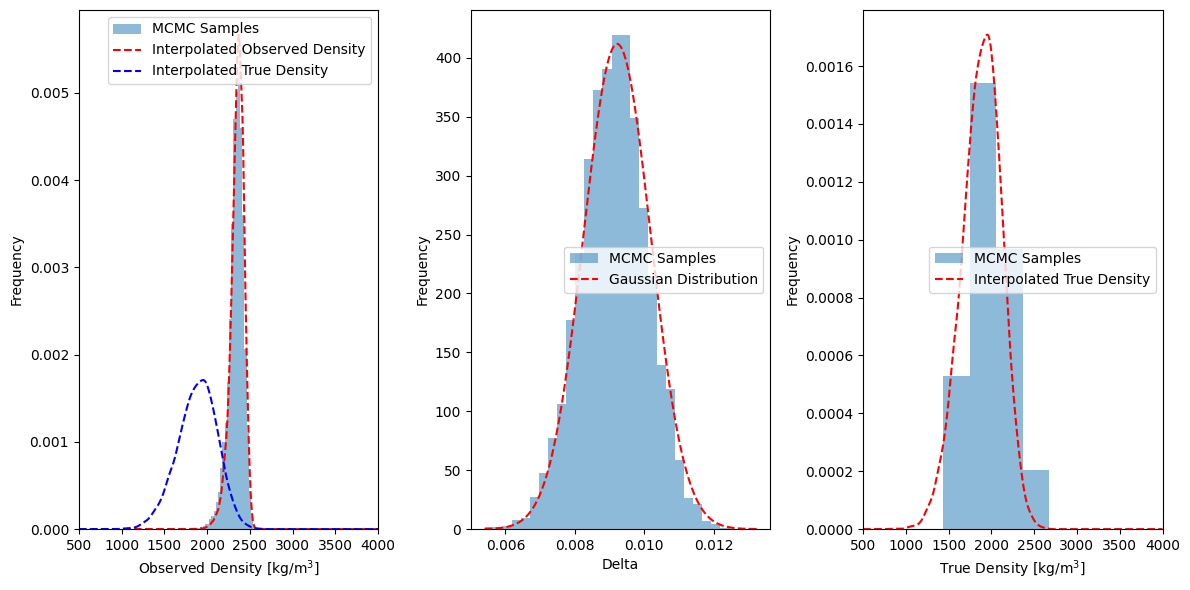

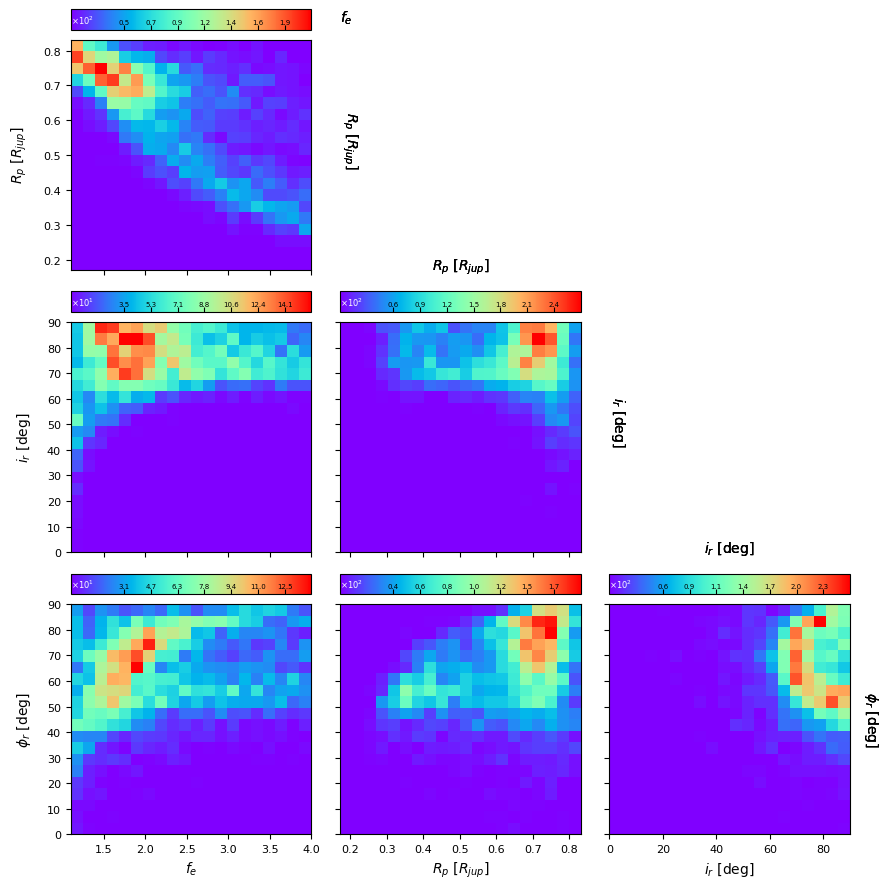

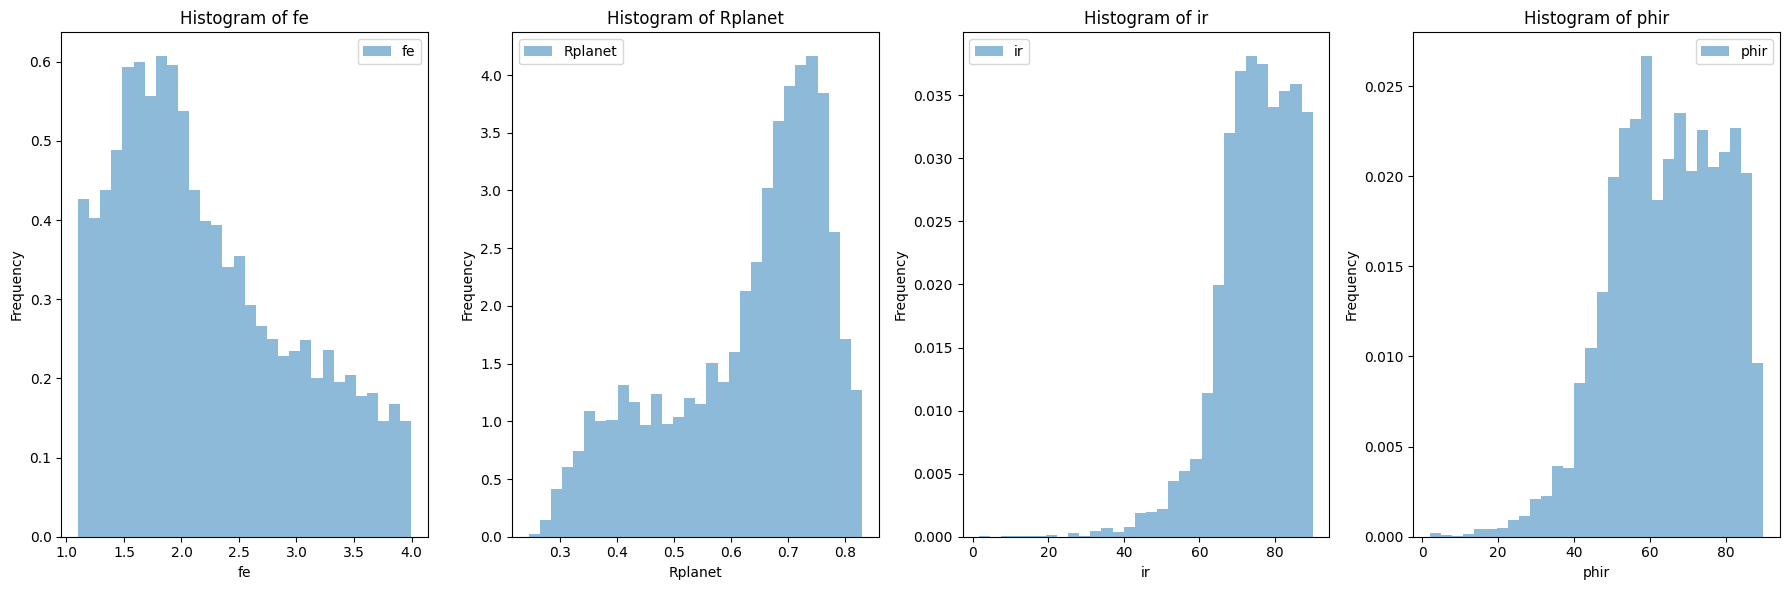

In [18]:
# Ns = int(1e4)
system_prefix = 'k51-planet_b'
sample_suffix = f"MR_simple_variance-N{Ns:.0e}"
Xs = pd.read_csv(f"tmp/ringed_sample-{system_prefix}-{sample_suffix}.csv")
plotSample(Xs,S,props,prefix=f"{system_prefix}-{sample_suffix}",
           csargs=dict(alpha=0),chargs=dict(bins=20))

Alternative plot:

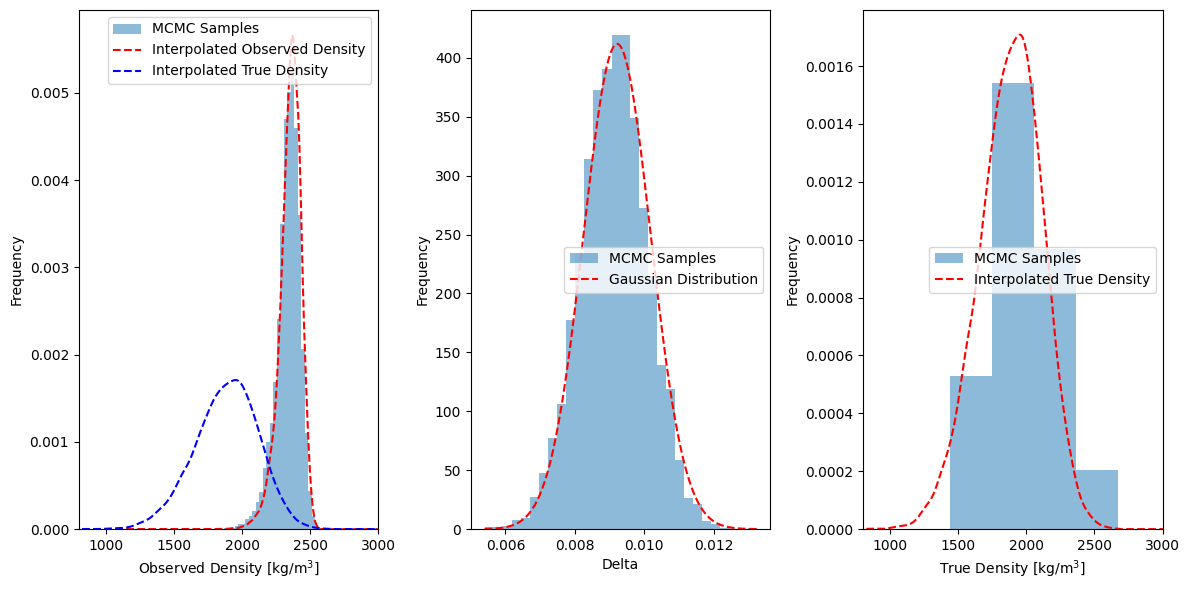

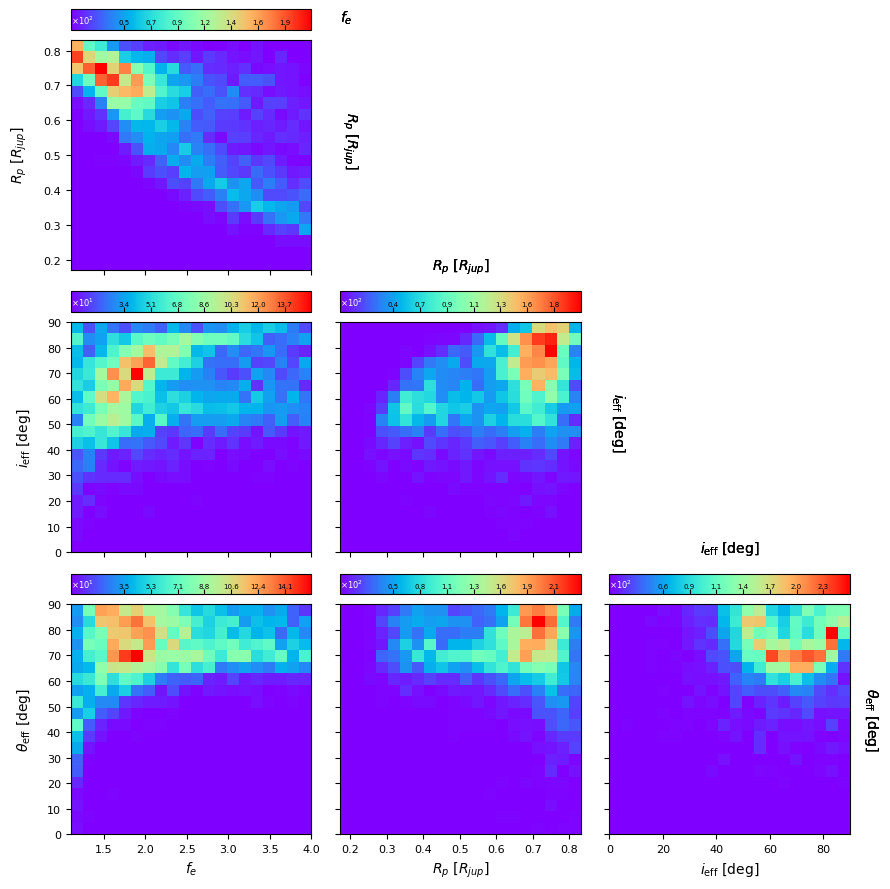

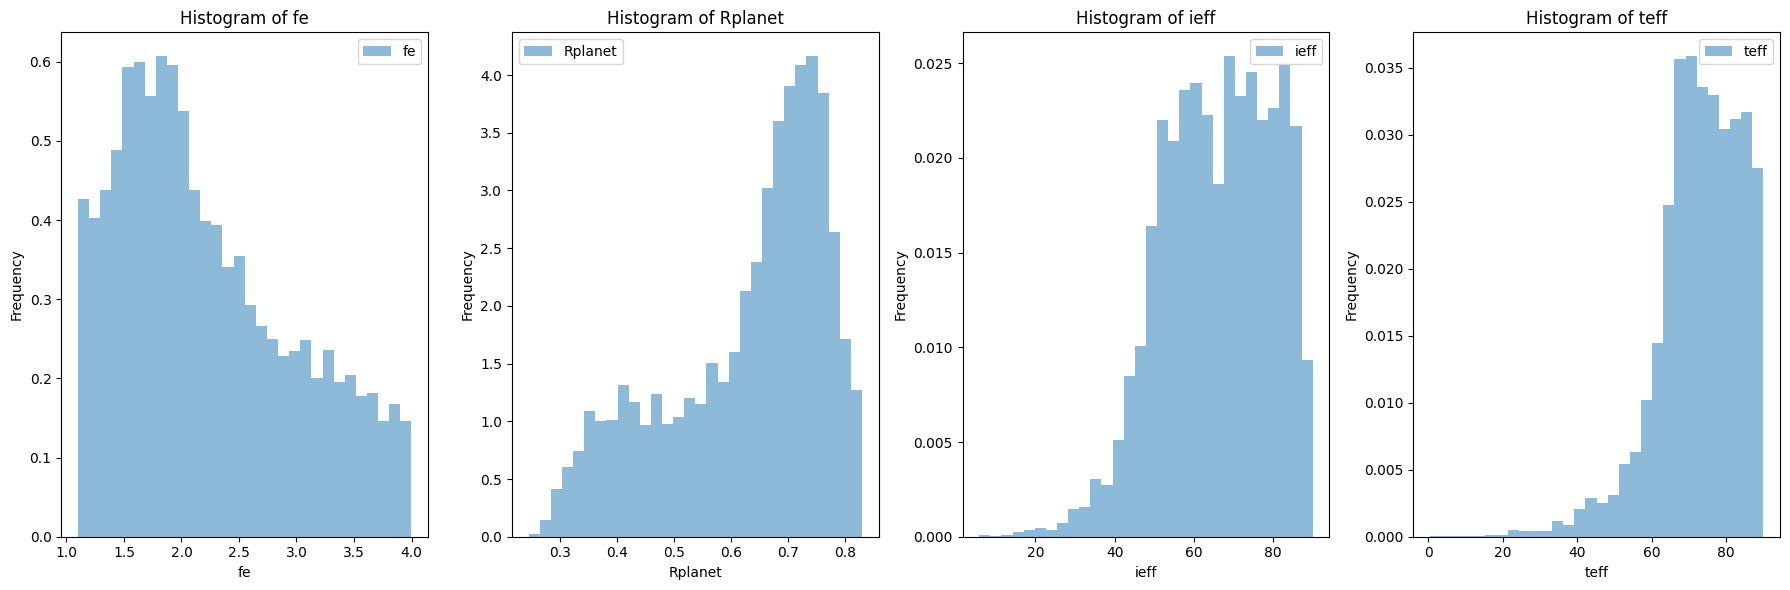

In [19]:
altprops = dict(
    fe = props['fe'],
    Rplanet = props['Rplanet'],
    ieff = dict(
        label=r"$i_{\rm eff}$ [deg]",
        range=[0,90],
    ),
    teff = dict(
        label=r"$\theta_{\rm eff}$ [deg]",
        range=[0,90],
    )
)
plotSample(Xs,S,altprops,prefix=f"{system_prefix}-{sample_suffix}-veff",rho_range=(800,3000),
           csargs=dict(alpha=0),chargs=dict(bins=20))

In [27]:
S = deepcopy(System_d)
S.tau = 1
S.fi = 1
system_prefix = 'k51-planet_d'

# Total size of the sample
Ns = int(1e3)

# Name of the sample
sample_suffix = f"MR_simple_variance-N{Ns:.0e}"

# Prepare the data
columns = [prop for prop,vals in props.items()]
Xs = pd.DataFrame([],columns=columns + ['rho_true', 'rho_obs', 'PR', 'ieff', 'teff', 'delta'])

# Loop over the grid
Nsamples = 0
n = 0 
for i in range(MS.shape[0]):
    for j in range(RS.shape[1]):
        n += 1 

        # Update stellar parameters
        S.Mstar = MS[i, j]*MSUN
        S.Rstar = RS[i, j]*RSUN
        S.updateSystem()
        
        # Calculate the number of samples required
        Np = int(PS[i,j]*Ns)
        
        print(f"Stellar parameters {n}: M_star = {S.Mstar/MSUN}, R_star = {S.Rstar/RSUN}, Number of samples: {Np}")

        start_time = time.time()
        results = parallel_mcra_grid(S, props, store_params, adjust_params, Nw, Np)
        end_time = time.time()
        execution_time = end_time - start_time
        print(f"\tExecution time: {execution_time:.2f} seconds")

        Nsamples += len(results)

        # Accumulate
        Xs = pd.concat([Xs,results], ignore_index=True)
        
        # Save accumulated
        Xs.to_csv(f"tmp/ringed_sample-{system_prefix}-{sample_suffix}.csv", index=False)
    
os.system('say "Tu programa ha terminado"')

Stellar parameters 1: M_star = 0.8150622084199416, R_star = 0.8110040099107445, Number of samples: 1
	Execution time: 0.03 seconds
Stellar parameters 2: M_star = 0.8648631458992002, R_star = 0.8110040099107445, Number of samples: 7
	Execution time: 0.09 seconds
Stellar parameters 3: M_star = 0.9146640833784587, R_star = 0.8110040099107445, Number of samples: 20
	Execution time: 0.78 seconds
Stellar parameters 4: M_star = 0.9644650208577173, R_star = 0.8110040099107445, Number of samples: 18
	Execution time: 0.53 seconds
Stellar parameters 5: M_star = 1.014265958336976, R_star = 0.8110040099107445, Number of samples: 5
	Execution time: 0.38 seconds
Stellar parameters 6: M_star = 0.8150622084199416, R_star = 0.8399178025856646, Number of samples: 7
	Execution time: 0.09 seconds
Stellar parameters 7: M_star = 0.8648631458992002, R_star = 0.8399178025856646, Number of samples: 46
	Execution time: 0.94 seconds
Stellar parameters 8: M_star = 0.9146640833784587, R_star = 0.8399178025856646, N

0

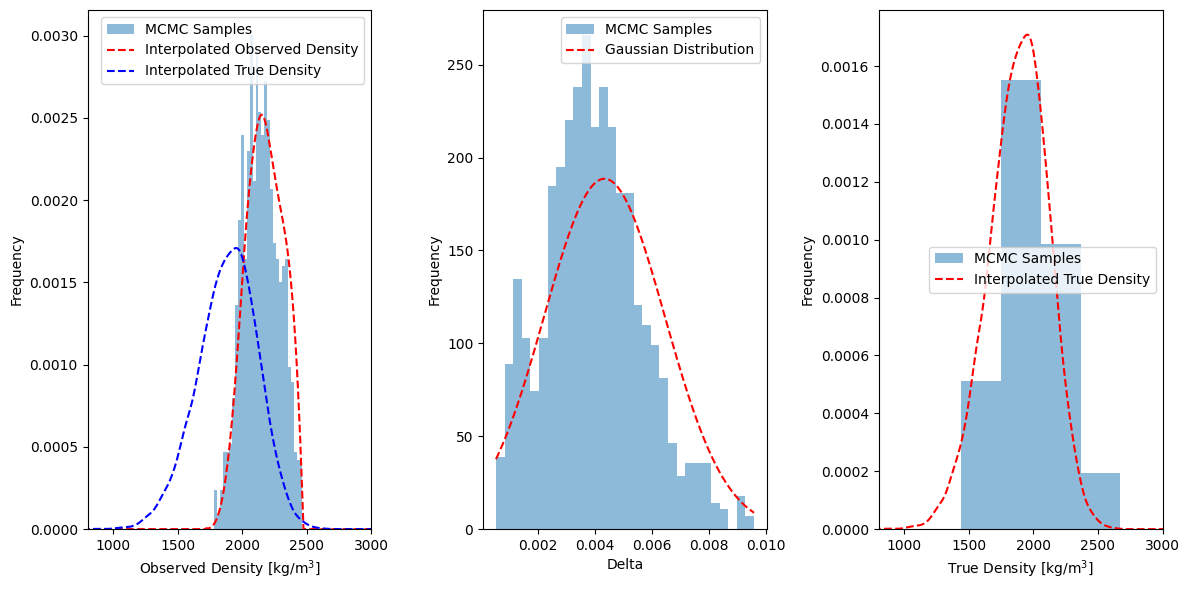

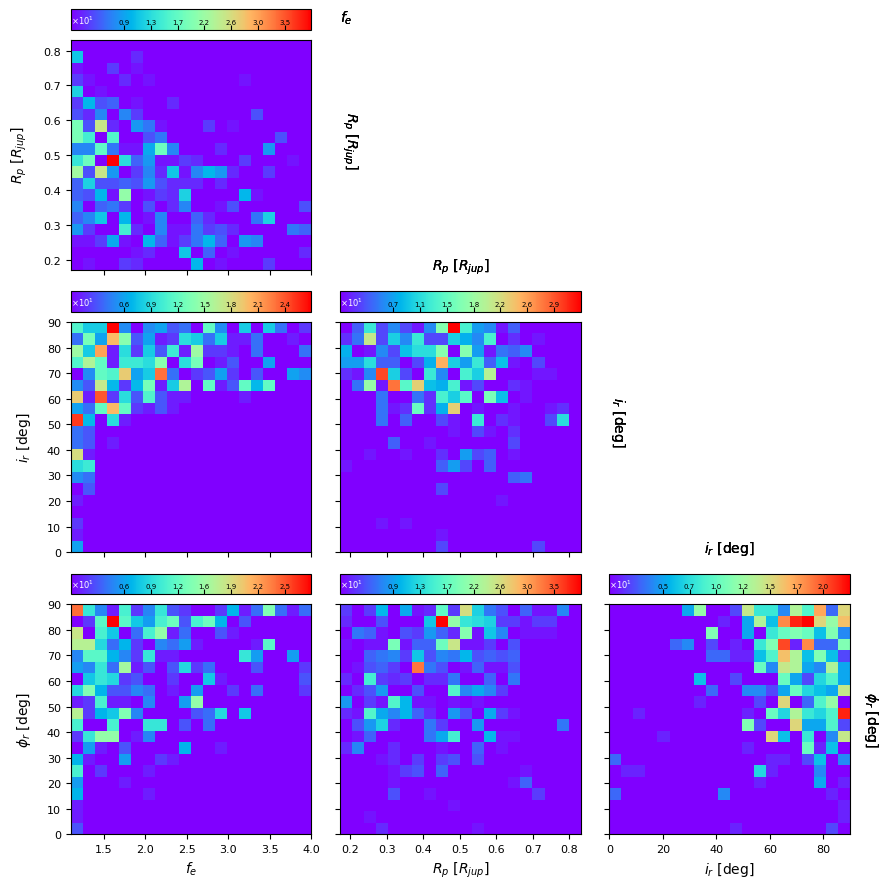

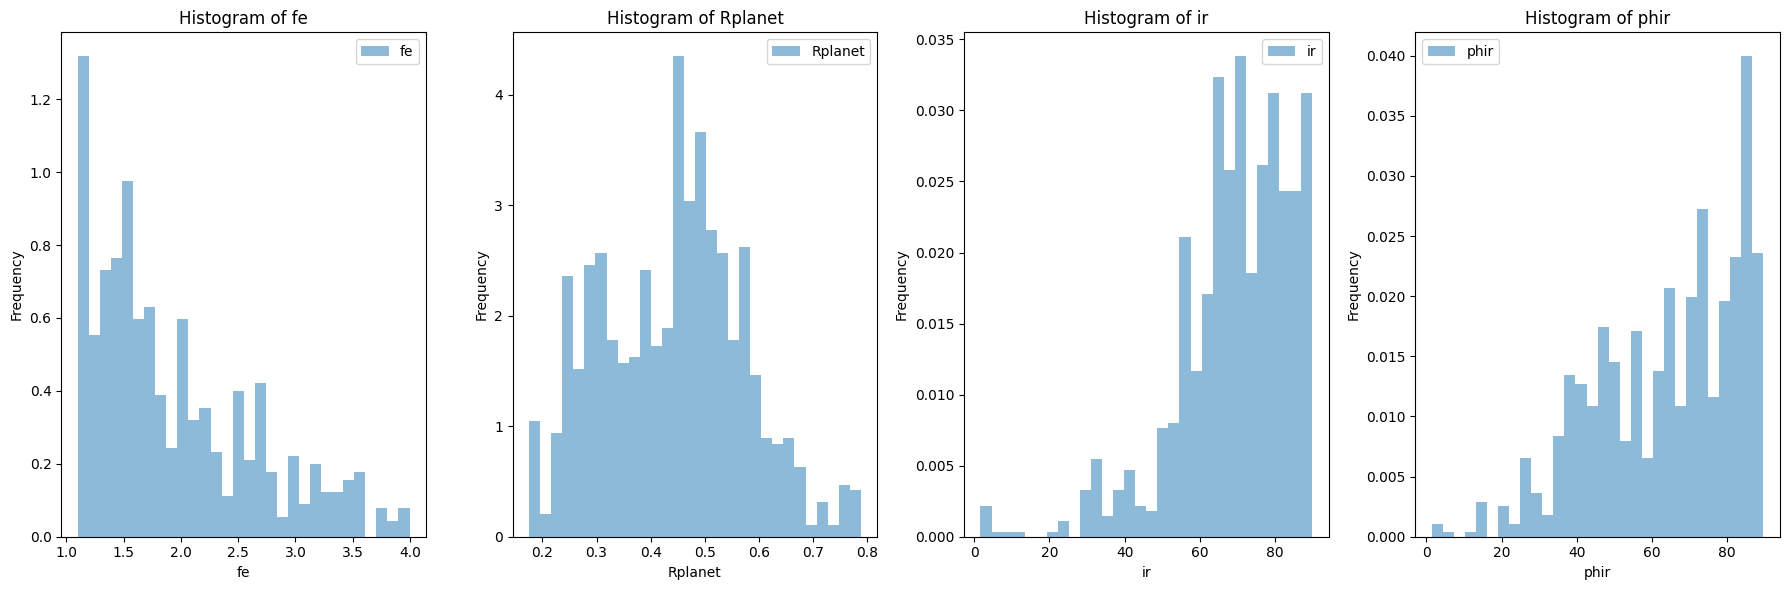

In [28]:
S = deepcopy(System_d)
#Ns = int(1e5)
system_prefix = 'k51-planet_d'
sample_suffix = f"MR_simple_variance-N{Ns:.0e}"
Xs = pd.read_csv(f"tmp/ringed_sample-{system_prefix}-{sample_suffix}.csv")
plotSample(Xs,S,props,prefix=f"{system_prefix}-{sample_suffix}",rho_range=(800,3000),
           csargs=dict(alpha=0),chargs=dict(bins=20))

Alternative plot:

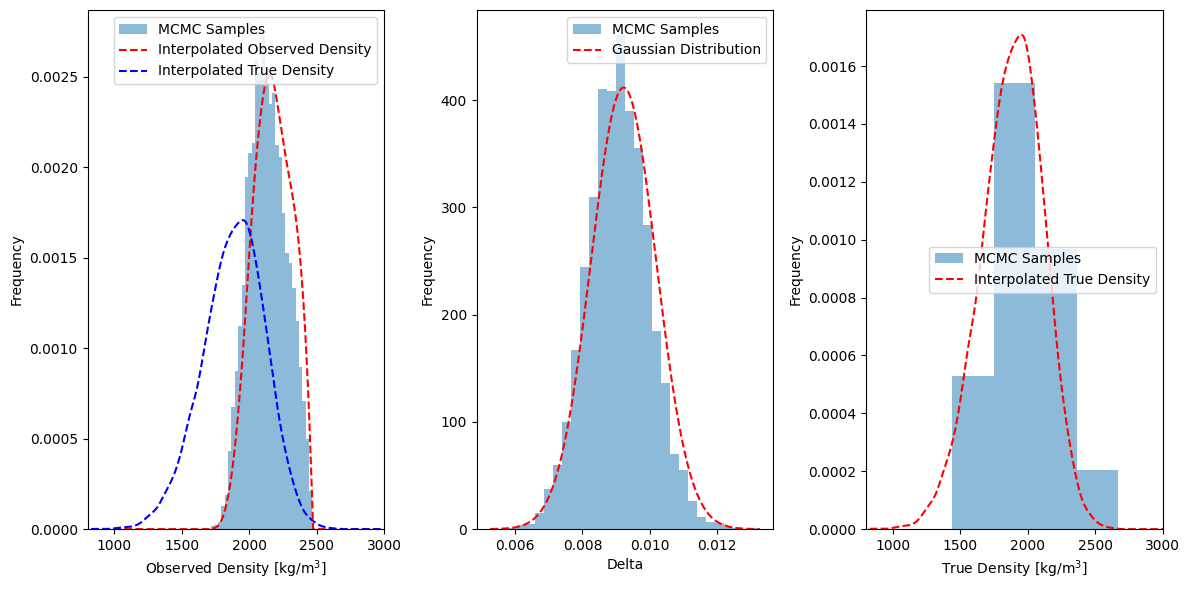

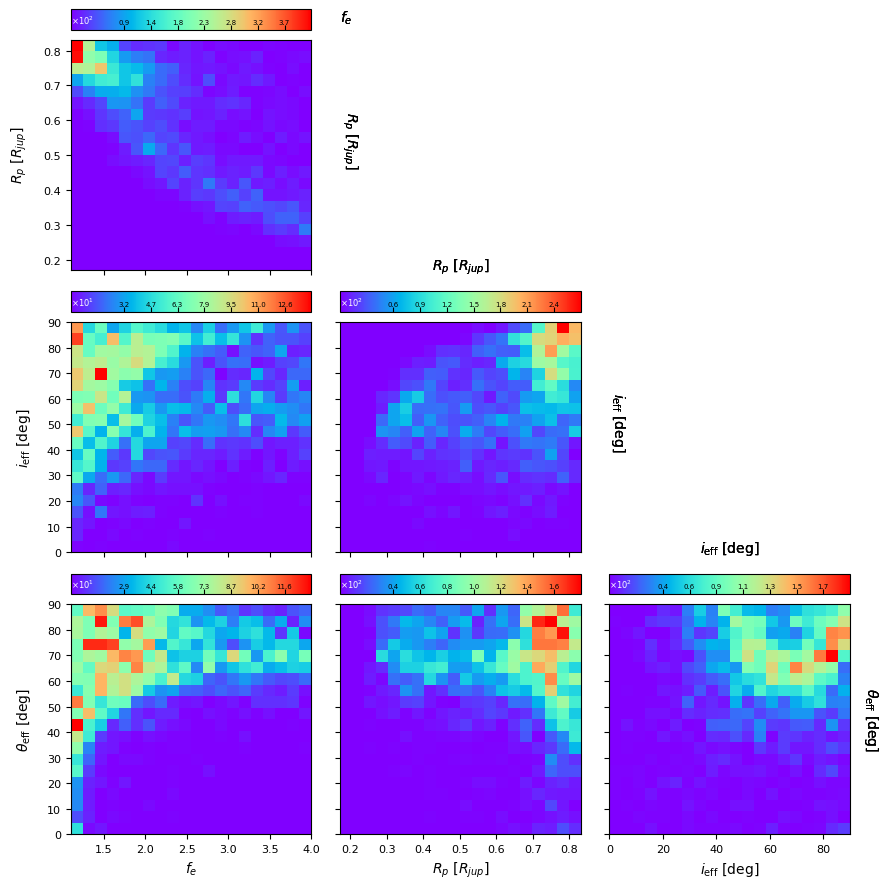

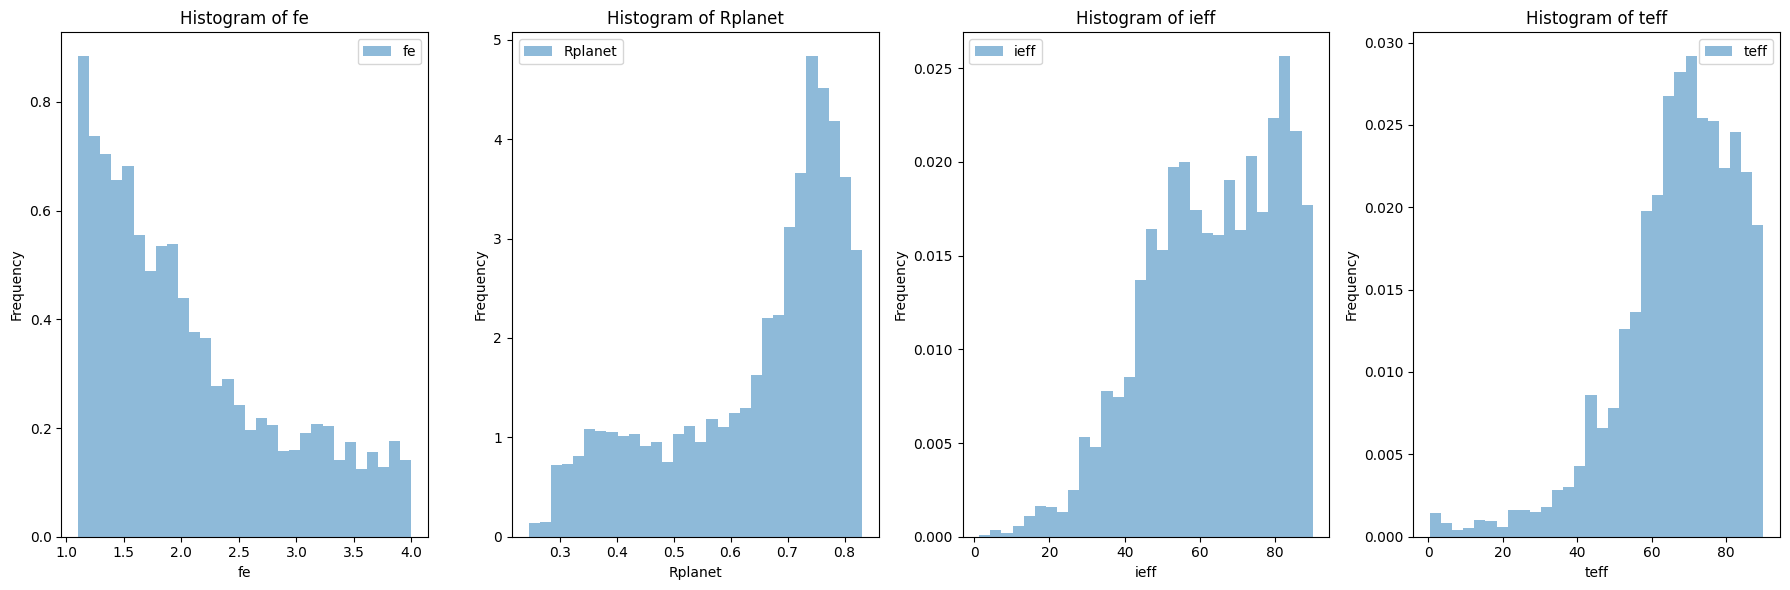

In [22]:
S = deepcopy(System_d)
#Ns = int(1e5)
system_prefix = 'k51-planet_d'
sample_suffix = f"MR_simple_variance-N{Ns:.0e}"
Xs = pd.read_csv(f"tmp/ringed_sample-{system_prefix}-{sample_suffix}.csv")

altprops = dict(
    fe = props['fe'],
    Rplanet = props['Rplanet'],
    ieff = dict(
        label=r"$i_{\rm eff}$ [deg]",
        range=[0,90],
    ),
    teff = dict(
        label=r"$\theta_{\rm eff}$ [deg]",
        range=[0,90],
    )
)
plotSample(Xs,S,altprops,prefix=f"{system_prefix}-{sample_suffix}-veff",rho_range=(800,3000),
           csargs=dict(alpha=0),chargs=dict(bins=20))

# The problematic planet c

The problem of this planet is that it is grazing:

In [32]:
# Columns are: Rp/R*, rho* (km/m^3), b, P (ignore), tmid,0 (ignore), q1, q2
data = np.loadtxt('Kepler-51/Kepler-51d_85d/TTVplan-post_equal_weights.dat')

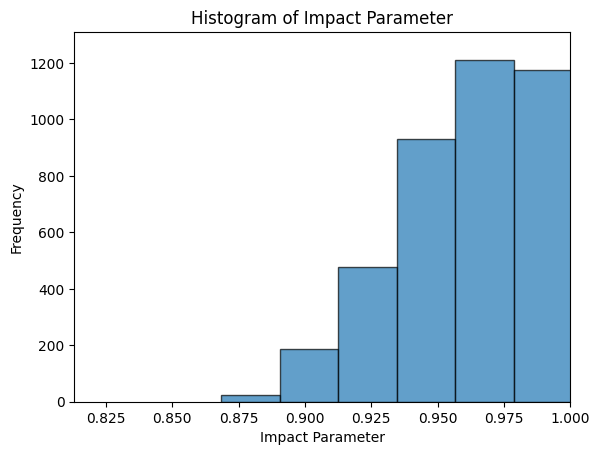

In [33]:
# Extract the impact parameter from column 2 of data
impact_parameter = data[:, 2]

# Plot the histogram
plt.hist(impact_parameter, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Impact Parameter')
plt.ylabel('Frequency')
plt.title('Histogram of Impact Parameter')
plt.xlim(plt.xlim()[0], 1)
plt.show()

Done.

In [136]:
S = deepcopy(System_c)
S.tau = 1
S.fi = 1
system_prefix = 'k51-planet_c'

debug = 0

# Total size of the sample
Ns = int(1e5)

# Name of the sample
sample_suffix = f"MR_simple_variance_modB-N{Ns:.0e}"

# Number of processors
Nw = 4

# Prepare the data
columns = [prop for prop,vals in props.items()]
Xs = pd.DataFrame([],columns=columns + ['rho_true', 'rho_obs', 'PR', 'ieff', 'teff', 'delta'])

# Loop over the grid
Nsamples = 0
n = 0 
for i in range(MS.shape[0]):
    for j in range(RS.shape[1]):
        n += 1 

        # Update stellar parameters
        S.Mstar = MS[i, j]*MSUN
        S.Rstar = RS[i, j]*RSUN
        S.updateSystem()
        
        # Calculate the number of samples required
        Np = int(PS[i,j]*Ns)
        
        print(f"Stellar parameters {n}: M_star = {S.Mstar/MSUN}, R_star = {S.Rstar/RSUN}, Number of samples: {Np}")

        start_time = time.time()
        if debug:
            results = mcra_grid_general(S, props, store_params, adjust_params, 
                                        Np, verbose=True, seed=42)
        else:
            results = parallel_mcra_grid(S, props, store_params, adjust_params, Nw, Np) 
        
        end_time = time.time()
        execution_time = end_time - start_time
        print(f"\tExecution time: {execution_time:.2f} seconds")

        Nsamples += len(results)

        # Accumulate
        Xs = pd.concat([Xs,results], ignore_index=True)
        
        # Save accumulated
        Xs.to_csv(f"tmp/ringed_sample-{system_prefix}-{sample_suffix}.csv", index=False)
        
        if debug:break

    if debug:break 

#os.system('say "Tu programa ha terminado"')

Stellar parameters 1: M_star = 0.8150622084199416, R_star = 0.8110040099107445, Number of samples: 10
	Execution time: 0.06 seconds
Stellar parameters 2: M_star = 0.8648631458992002, R_star = 0.8110040099107445, Number of samples: 79
	Execution time: 0.16 seconds
Stellar parameters 3: M_star = 0.9146640833784587, R_star = 0.8110040099107445, Number of samples: 202
	Execution time: 0.36 seconds
Stellar parameters 4: M_star = 0.9644650208577173, R_star = 0.8110040099107445, Number of samples: 182
	Execution time: 0.35 seconds
Stellar parameters 5: M_star = 1.014265958336976, R_star = 0.8110040099107445, Number of samples: 57
	Execution time: 0.15 seconds
Stellar parameters 6: M_star = 0.8150622084199416, R_star = 0.8399178025856646, Number of samples: 79
	Execution time: 0.15 seconds
Stellar parameters 7: M_star = 0.8648631458992002, R_star = 0.8399178025856646, Number of samples: 465
	Execution time: 0.72 seconds
Stellar parameters 8: M_star = 0.9146640833784587, R_star = 0.839917802585

In [137]:
Xs

,fe,Rplanet,ir,phir,rho_true,rho_obs,PR,ieff,teff,delta,Rstar,Mstar,ap,ep,iorb,Borb,Porb,tT,grazing
0,3.396003,0.377966,51.124010,83.303697,2148.334421,958.605254,-0.350462,85.068699,50.901965,0.003568,0.811004,0.815062,0.354287,0.0,89.560433,-0.72,85.313011,5.773150,0.0
1,2.955771,0.220811,85.020203,46.966349,2148.334421,1718.254985,-0.097014,47.221501,82.798038,0.003588,0.811004,0.815062,0.354287,0.0,89.560433,-0.72,85.313011,5.474062,0.0
2,2.309364,0.455998,0.010294,27.209932,2148.334421,1073.458974,-0.301316,89.569588,0.004707,0.003246,0.811004,0.815062,0.354287,0.0,89.560433,-0.72,85.313011,5.724926,0.0
3,2.315664,0.441688,18.400702,79.030569,2148.334421,1250.844489,-0.234899,86.974280,18.078866,0.003386,0.811004,0.815062,0.354287,0.0,89.560433,-0.72,85.313011,5.641583,0.0
4,2.057971,0.245796,55.734387,26.968921,2148.334421,1831.037879,-0.069405,42.926965,33.388040,0.002375,0.811004,0.815062,0.354287,0.0,89.560433,-0.72,85.313011,5.350593,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9763,3.044356,0.332480,50.282085,12.634824,1792.139804,1452.892104,-0.091139,41.811673,14.617876,0.006960,0.926659,1.014266,0.381073,0.0,89.533052,-0.72,85.313185,6.114474,0.0
9764,2.057971,0.245796,55.734387,26.968921,1792.139804,1527.410035,-0.069416,42.949829,33.371850,0.001819,0.926659,1.014266,0.381073,0.0,89.533052,-0.72,85.313185,5.614665,0.0
9765,2.901288,0.378067,12.112195,46.222031,1792.139804,923.044523,-0.288149,82.114217,8.797732,0.002801,0.926659,1.014266,0.381073,0.0,89.533052,-0.72,85.313185,5.992493,0.0
9766,1.922223,0.444916,39.640835,14.118096,1792.139804,1535.102368,-0.067235,52.236271,11.352583,0.004685,0.926659,1.014266,0.381073,0.0,89.533052,-0.72,85.313185,5.916388,0.0


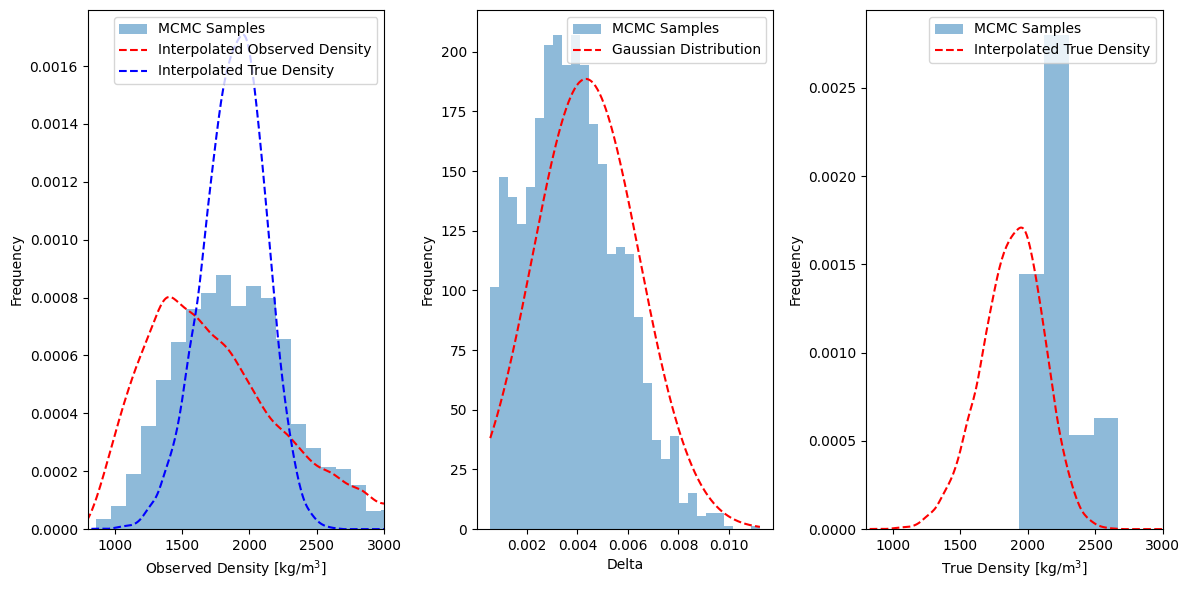

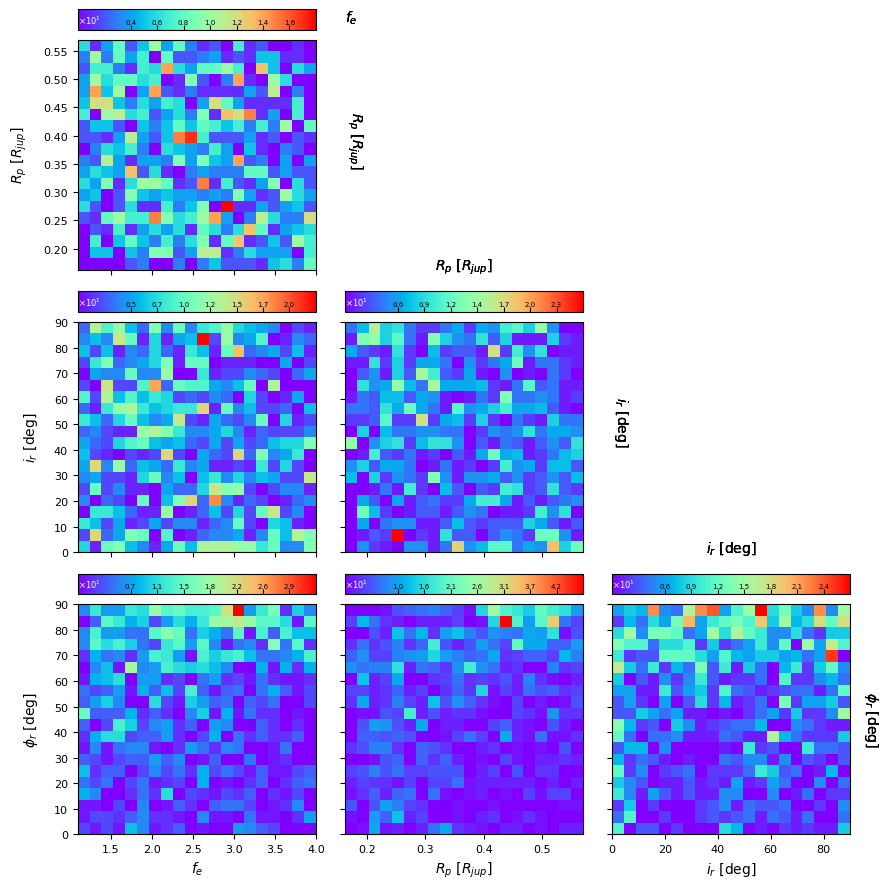

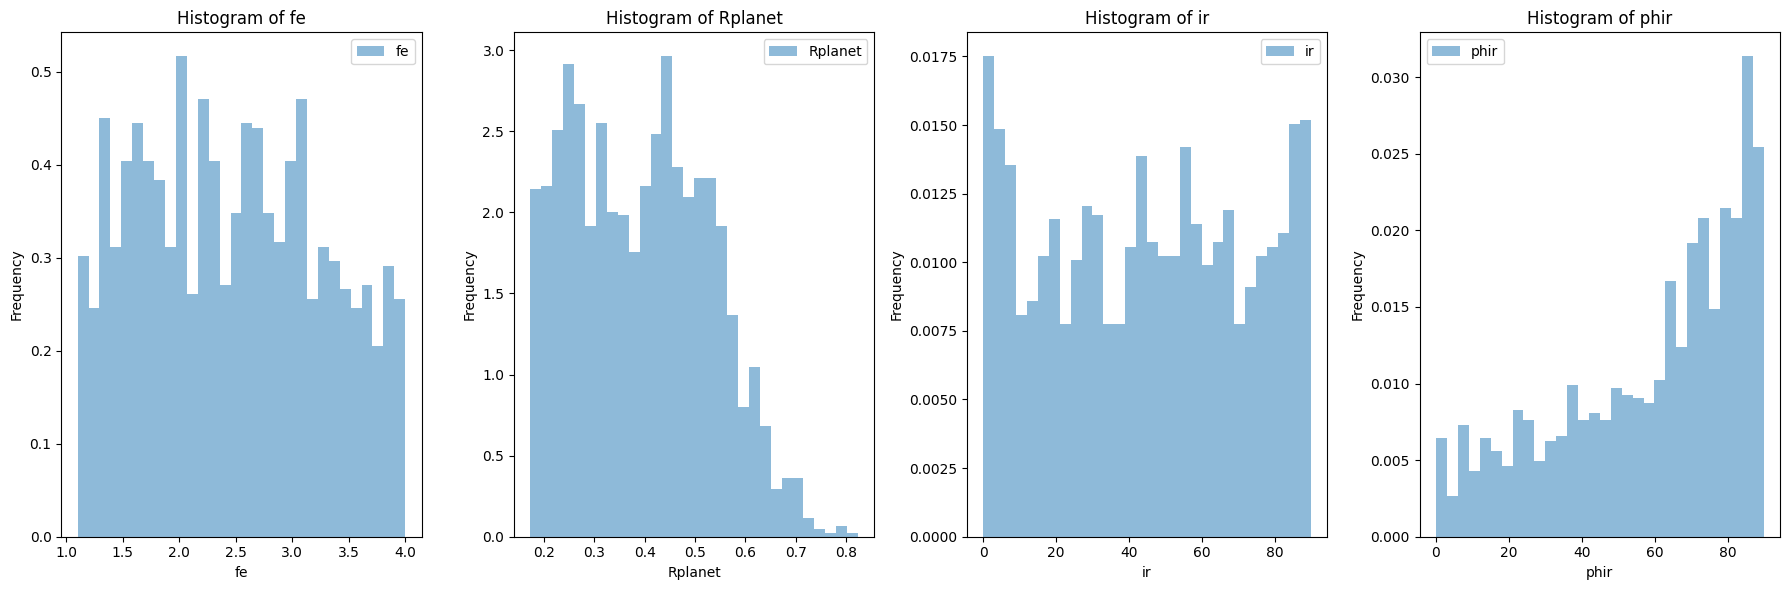

In [141]:
S = deepcopy(System_c)
# Ns = int(1e4)
system_prefix = 'k51-planet_c'
sample_suffix = f"MR_simple_variance-N{Ns:.0e}"
Xs = pd.read_csv(f"tmp/ringed_sample-{system_prefix}-{sample_suffix}.csv")
plotSample(Xs,S,props,prefix=f"{system_prefix}-{sample_suffix}",rho_range=(800,3000),
           csargs=dict(alpha=0),chargs=dict(bins=20))